In [8]:
from astroquery.sdss import SDSS
import pandas as pd

sql = """
SELECT TOP 100000
    p.objID,
    s.specobjID,
    s.z,
    s.zWarning,
    s.zErr,
    s.class,
    p.clean,
    p.modelMag_u - p.modelMag_g AS color_ug,
    p.modelMag_g - p.modelMag_r AS color_gr,
    p.modelMag_r - p.modelMag_i AS color_ri,
    p.modelMag_i - p.modelMag_z AS color_iz,
    p.psfMag_r   - p.modelMag_r AS star_galaxy_sep,
    p.petroR90_r / NULLIF(p.petroR50_r, 0) AS concentration

FROM PhotoObj AS p
JOIN SpecObj AS s ON s.bestObjID = p.objID
WHERE s.class = 'GALAXY'
  AND s.zWarning = 0
  AND s.z BETWEEN 0.02 AND 0.35
  AND p.clean = 1
ORDER BY NEWID()
"""

tab = SDSS.query_sql(sql, data_release=17)

import numpy as np
unique, counts = np.unique(tab['zWarning'], return_counts=True)
print(dict(zip(unique, counts)))
df  = tab.to_pandas()                         # -> pandas DataFrame


{np.int64(0): np.int64(100000)}


In [9]:
df.head()

,objID,specobjID,z,zWarning,zErr,class,clean,color_ug,color_gr,color_ri,color_iz,star_galaxy_sep,concentration
0,1237679077516771555,7921924213732300800,0.211709,0,0.000036,GALAXY,1,1.986822,1.389606,0.544777,0.422182,1.268522,3.034398
1,1237678880490061956,4922557356104243200,0.236853,0,0.000029,GALAXY,1,2.014561,1.466772,0.535290,0.360819,1.480629,3.066611
2,1237667253465120891,2639169092891731968,0.044924,0,0.000024,GALAXY,1,1.292788,0.530792,0.303461,0.212759,3.116728,2.179162
3,1237658192149020872,1050545471514241024,0.164707,0,0.000014,GALAXY,1,1.288698,0.832909,0.457193,0.272154,1.625265,2.069316
4,1237664818748915727,2291328963617777664,0.169328,0,0.000014,GALAXY,1,1.503536,0.812944,0.468863,0.194305,1.489437,2.267564


In [10]:
len(df)

100000

In [22]:
clean_df = df.drop(columns=['objID', 'specobjID', 'class', 'zWarning', 'clean'])
clean_df.head()

,z,zErr,color_ug,color_gr,color_ri,color_iz,star_galaxy_sep,concentration
0,0.211709,0.000036,1.986822,1.389606,0.544777,0.422182,1.268522,3.034398
1,0.236853,0.000029,2.014561,1.466772,0.535290,0.360819,1.480629,3.066611
2,0.044924,0.000024,1.292788,0.530792,0.303461,0.212759,3.116728,2.179162
3,0.164707,0.000014,1.288698,0.832909,0.457193,0.272154,1.625265,2.069316
4,0.169328,0.000014,1.503536,0.812944,0.468863,0.194305,1.489437,2.267564


In [23]:
target = clean_df['z']

correlations = clean_df.corrwith(target)

print(correlations)

z                  1.000000
zErr               0.006216
color_ug           0.414135
color_gr           0.009998
color_ri           0.541206
color_iz          -0.001536
star_galaxy_sep   -0.415054
concentration      0.177276
dtype: float64


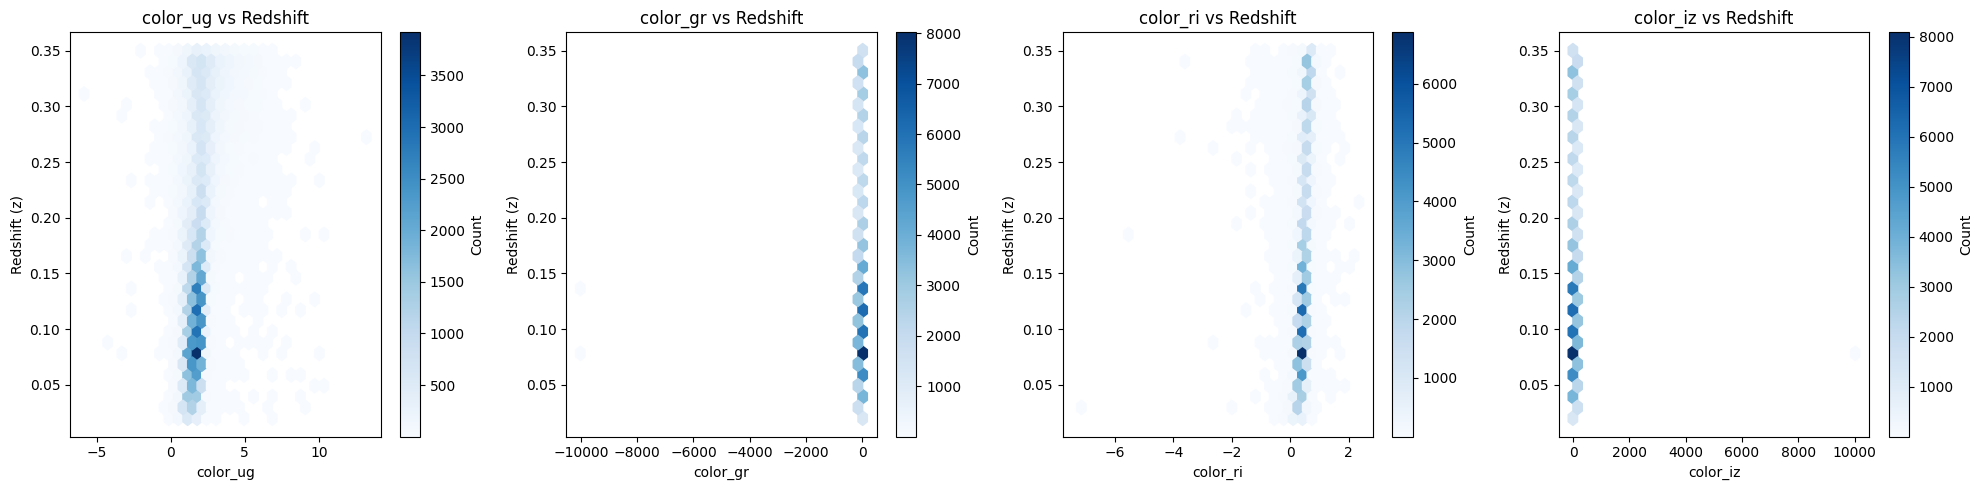

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming df is your DataFrame with columns 'z', 'color_ug', 'color_gr', etc.

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors_to_plot = ['color_ug', 'color_gr', 'color_ri', 'color_iz']

for ax, col in zip(axes, colors_to_plot):
    # Hexbin plot shows density of points, revealing trends in crowded areas
    hb = ax.hexbin(df[col], df['z'], gridsize=30, cmap='Blues', mincnt=1)
    ax.set_xlabel(col)
    ax.set_ylabel('Redshift (z)')
    ax.set_title(f'{col} vs Redshift')
    plt.colorbar(hb, ax=ax, label='Count')

plt.tight_layout()
plt.show()


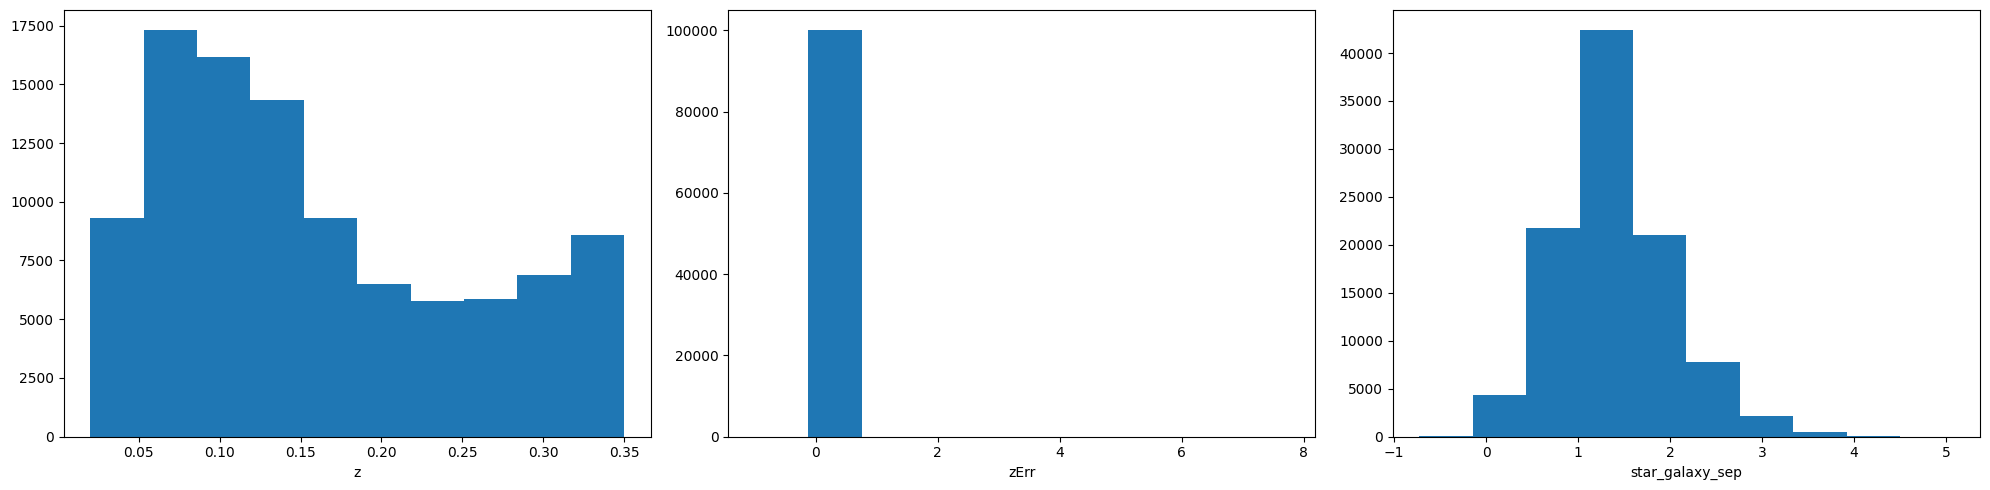

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors_to_plot = ['z','zErr', 'star_galaxy_sep', 'concentration']

for ax, col in zip(axes, colors_to_plot):
    hist = ax.hist(df[col])
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()


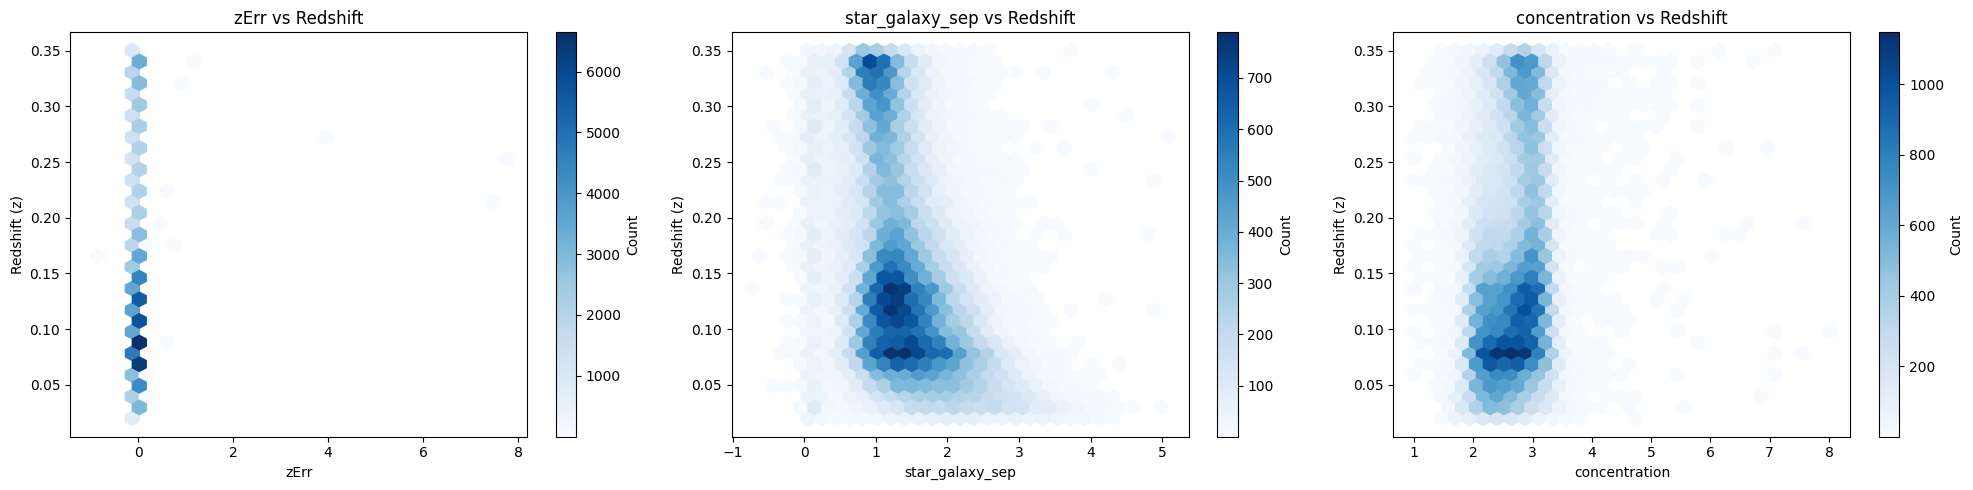

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors_to_plot = ['zErr', 'star_galaxy_sep', 'concentration']

for ax, col in zip(axes, colors_to_plot):
    # Hexbin plot shows density of points, revealing trends in crowded areas
    hb = ax.hexbin(df[col], df['z'], gridsize=30, cmap='Blues', mincnt=1)
    ax.set_xlabel(col)
    ax.set_ylabel('Redshift (z)')
    ax.set_title(f'{col} vs Redshift')
    plt.colorbar(hb, ax=ax, label='Count')

plt.tight_layout()
plt.show()


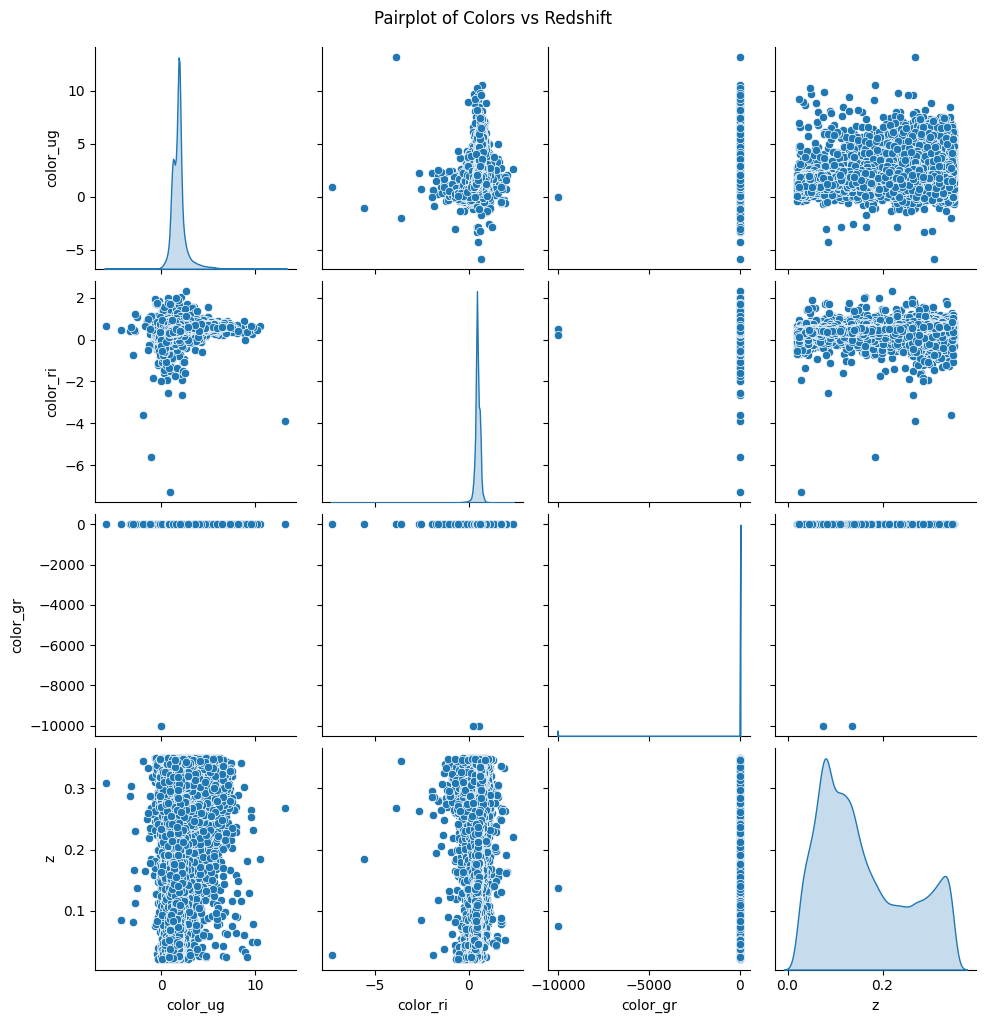

In [32]:
import seaborn as sns
# Pairplot for key features and target
sns.pairplot(df[['color_ug', 'color_ri', 'color_gr', 'z']], diag_kind='kde')
plt.suptitle("Pairplot of Colors vs Redshift", y=1.02)
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X = clean_df.drop(columns=['z'])
y = clean_df['z']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestRegressor(n_estimators=700, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Abs Error:  {mae:.3f}")

In [ ]:
import xgboost as xgb
xgb_model = clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2)


early_stop = xgb.callback.EarlyStopping(
    rounds=2, metric_name='logloss', data_name='validation_0', save_best=True
)
clf = xgb.XGBClassifier(tree_method="hist", callbacks=[early_stop])
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)])

train_score = clf.score(X_train, y_train)
test_score = clf.score(X_test, y_test)

print('train score: ', train_score)
print('test score: ', test_score)
